# Trotterized Hamiltonian Simulation

- Using the `ham_sim_trotter` function from Guppy Algorithms, we can simulate the time evolution of a quantum system under a given Hamiltonian

- We will compare the results from Guppy with a statevector evolution to verify the simulation


In [1]:
from guppylang import guppy
from guppylang.std.builtins import comptime
from scipy.linalg import expm
import numpy as np
from guppylang.std.quantum import ry, measure_array, collect_measurements
from guppylang.std.angles import angle
from guppyalgos.utils import qarray
from guppyalgos.algorithms.time_evolution.trotter import trotter_first_order, ham_sim_trotter
from guppylang.std.builtins import output
import zixy.qubit.pauli as zqp

- First a real Hamiltonian operator is defined using Pauli strings and coefficients.

In [2]:
ham_op = zqp.RealTermSum.from_str("(-0.5, Z0 X1), (-0.1, X0 Z1), (-0.2, Y0 Y1), (-0.3, X0 X1)")

- Next, we define a function for the trotter step.
- Currently, we use `trotter_first_order`, however higher-order methods can be implemented similarly as long as the function signature matches.

In [3]:
time_step = 0.2
n_steps_list = list(range(1, 20))
n_state_qubits = len(ham_op.qubits)

trotter_step = trotter_first_order(ham_op, n_state_qubits)

- The trotterized Hamiltonian simulation is then constructed using the `ham_sim_trotter` function, specifying the Hamiltonian, time, and number of steps.
- Inside this function the trotter step function is used iteratively `n_steps` times to build the full simulation.
- Then, we run the Guppy program

In [4]:
def time_evolve(trotter_step, time_step, n_steps, n_state_qubits, n_sim_qubits):

    ham_sim = ham_sim_trotter(trotter_step, n_steps, time_step, n_state_qubits)

    @guppy
    def main() -> None:

        state_qreg = qarray(comptime(n_state_qubits))

        for i in range(len(state_qreg)):
            ry(state_qreg[i], angle(0.5)) #arbitrary initial state

        ham_sim(state_qreg)
        output("state", collect_measurements(measure_array(state_qreg)))



    my_shots = main.emulator(n_qubits=n_sim_qubits).with_shots(1000).run()
    return my_shots.collated_shots()

- The `time evolve` function computes the exact time evolution of the initial state or varying time numbers of time steps

In [5]:
time_shots ={i:time_evolve(trotter_step, time_step, i, n_state_qubits, n_state_qubits) for i in n_steps_list}

- The shot results are then collected and averaged for each qubit

In [6]:
time_points = {}
for time, res in time_shots.items(): 
    a = np.array([shot['state'][0] for shot in res])
    av_q0 = np.mean(a[:,0])
    av_q1 = np.mean(a[:,1])
    time_points[time] = (av_q0, av_q1)

In [7]:
from pandas import DataFrame
df_guppy = DataFrame.from_dict(time_points, orient='index', columns=['Q0 Avg (Guppy Rz)', 'Q1 Avg (Guppy Rz)'])

- For comparison, we compute the exact statevector evolution using matrix exponentiation and compare the probabilities with those obtained from the Guppy simulation.

In [8]:
from pytket.circuit import Circuit
from numpy.linalg import matrix_power

def compute_expected_statevector(ham_op, time_step, n_steps, n_state_qubits):

    def pauli_exp_matrix(term, time_step):
        pauli_mat = zqp.RealTermSum.from_iterable([term], term.qubits).to_sparse_matrix(True).todense()
        return expm(-1j * (0.5 * np.pi * (time_step)) * pauli_mat)

    # Excluding identity terms as guppy does not handle global phase yet
    ham_terms = [
        term.clone() for term in ham_op.to_terms() if not term.string.is_identity()
    ]

    pauli_exp_matrices = [pauli_exp_matrix(term, time_step) for term in ham_terms]

    step_u = np.eye(2**n_state_qubits, dtype=complex)
    for mat in pauli_exp_matrices:
        step_u = mat @ step_u

    expected_u = matrix_power(step_u, n_steps)

    sv = Circuit(2).Ry(0.5,0).Ry(0.5,1).get_statevector()
    
    expected_sv = expected_u @ sv

    #calculate probabilities of each basis state
    prob = np.abs(expected_sv)**2

    prob_2d = prob.reshape(2, 2)  # rows=q0, cols=q1

    av_q0 = prob_2d[1, :].sum()
    av_q1 = prob_2d[:, 1].sum()
    av_bits = [av_q0,av_q1]
    
    return av_bits

In [9]:
times = {}
for n in range(1, 20):
    av_bits = compute_expected_statevector(ham_op, time_step, n, n_state_qubits)
    times[n] = av_bits


In [10]:
df_num = DataFrame.from_dict(times, orient='index', columns=['Q0 Avg (Num)', 'Q1 Avg (Num)'])

- It can be seen the the numerical and the guppy simulations match closely

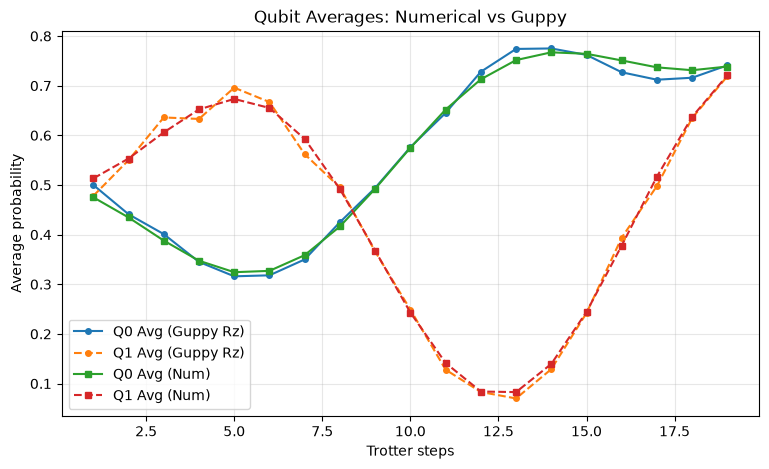

In [11]:
import pandas as pd
combined_df = pd.concat([df_guppy, df_num], axis=1)

# Plot together on the same axes with distinct styles
ax = combined_df.plot(
    figsize=(9, 5),
    style=['-o', '--o', '-s', '--s'],  # Q0 Sim, Q0 Exp, Q1 Sim, Q1 Exp
    linewidth=1.5,
    markersize=4,
    title='Qubit Averages: Numerical vs Guppy'
)

ax.set_xlabel('Trotter steps')
ax.set_ylabel('Average probability')
ax.grid(True, alpha=0.3)



## Repeat Until Success Rz Rotation

- The Trotter step function is flexible enough to allow for other $R_z(\theta)$ callable injections, such as arbitrary single qubit rotations using the `ComparatorBasedRz` struct from arXiv:2404.05618 "Single-qubit rotation algorithm with logarithmic Toffoli count and gate depth"
- This function constructs a repeat-until-success circuit that implements an Rz rotation with a specified angle and error tolerance using comparator-based logic.
- The number of ancilla qubits required depends on the desired error tolerance, with more ancilla qubits allowing for smaller errors.
- The smaller the angle the lower chance of success, and thus more repetitions on average, but the error can be made exponentially small by increasing the number of ancillas.

In [12]:
from guppyalgos.primitives.rotations import comparator_based_rz_cascade, n_comparator_based_rz_cascade_ancillas
from selene_sim import Quest
from guppylang.std.debug import state_result
from guppylang.std.quantum import discard_array, qubit

def time_evolve_rus(trotter_step, time_step, n_steps, n_state_qubits, n_ancilla):

    ham_sim = ham_sim_trotter(trotter_step, n_steps, time_step, n_state_qubits)

    @guppy
    def main() -> None:

        state_qreg = qarray(comptime(n_state_qubits))

        for i in range(len(state_qreg)):
            ry(state_qreg[i], angle(0.5)) #arbitrary initial state

        ham_sim(state_qreg)
        state_result("state", state_qreg)
        discard_array(state_qreg)

    em_result = main.emulator(n_state_qubits + n_ancilla).with_seed(1).run()
    states = Quest.extract_states_dict(em_result.results[0])
    guppy_sv = states["state"].get_single_state()
    return guppy_sv

- The emulator executes the actual repeat-until-success loop, including the measurements used by the temporary-AND uncomputation and any failed comparator attempts. `get_single_state()` extracts the recorded logical register without assuming that the measured ancillas occupy the all-zero basis block.

In [13]:
EPSILON = 0.01
N_ANCILLAS = n_comparator_based_rz_cascade_ancillas(EPSILON)

rus_rz = comparator_based_rz_cascade(EPSILON)

time_step = 0.2
n_steps_list = list(range(1, 20))
n_state_qubits = len(ham_op.qubits)

trotter_step = trotter_first_order(ham_op, n_state_qubits, rz_method=rus_rz)

times_sv ={i:time_evolve_rus(trotter_step, time_step, i, n_state_qubits, N_ANCILLAS) for i in n_steps_list}

time_points = {}
for time, sv in times_sv.items(): 

    prob = np.abs(sv)**2
    prob_2d = prob.reshape(2, 2)  # rows=q0, cols=q1

    av_q0 = prob_2d[1, :].sum()
    av_q1 = prob_2d[:, 1].sum()
    av_bits = [av_q0,av_q1]
    time_points[time] = av_bits
    

df_rus = DataFrame.from_dict(time_points, orient='index', columns=['Q0 Avg (Guppy RUS)', 'Q1 Avg (Guppy RUS)'])

#concatenate with previous dataframes for comparison
combined_df = pd.concat([combined_df, df_rus], axis=1)



- The dynamics can be see to agree closely with the exact statevector evolution, demonstrating the correctness of the repeat-until-success Rz rotation implementation.

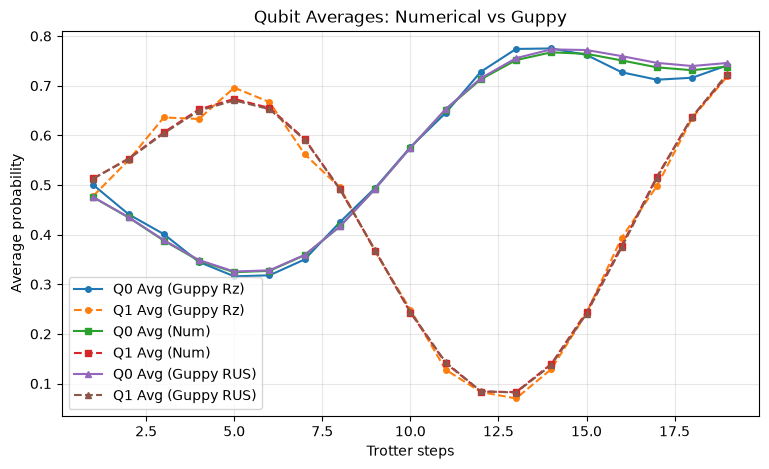

In [14]:
ax = combined_df.plot(
    figsize=(9, 5),
    style=['-o', '--o', '-s', '--s', '-^', '--^'],  # Q0 Sim, Q0 Exp, Q1 Sim, Q1 Exp, Q0 RUS, Q1 RUS
    linewidth=1.5,
    
    markersize=4,
    title='Qubit Averages: Numerical vs Guppy'
)

ax.set_xlabel('Trotter steps')
ax.set_ylabel('Average probability')
ax.grid(True, alpha=0.3)

In [15]:
combined_df

,Q0 Avg (Guppy Rz),Q1 Avg (Guppy Rz),Q0 Avg (Num),Q1 Avg (Num),Q0 Avg (Guppy RUS),Q1 Avg (Guppy RUS)
1,0.500,0.478,0.475141,0.513186,0.475352,0.512862
2,0.441,0.550,0.434553,0.553215,0.435163,0.552154
3,0.401,0.636,0.387963,0.605908,0.389005,0.603961
4,0.345,0.633,0.347378,0.652247,0.348714,0.649599
5,0.316,0.696,0.324289,0.673285,0.325653,0.670404
6,0.318,0.667,0.326982,0.655122,0.328074,0.652618
7,0.350,0.562,0.358595,0.592754,0.359203,0.591175
8,0.425,0.495,0.416372,0.491822,0.416475,0.491465
9,0.494,0.366,0.492286,0.367846,0.492112,0.368626
10,0.576,0.249,0.574872,0.243049,0.574879,0.244499
